# MediaPipe Valid Dataset Analysis - ASL

This notebook analyzes the valid `asl_landmarks_mediapipe.csv` file: the dataset already extracted with MediaPipe and ready to be used for training.

Important point: the landmark coordinates are not raw pixel coordinates. They are already normalized relative to the wrist:

- landmark `0` is the wrist;
- each landmark is shifted by subtracting the wrist position;
- the result is divided by a hand scale, computed as the distance between the wrist and the base of the middle finger (`landmark 9`).

Therefore `x0`, `y0`, and `z0` should be approximately `0`, because they represent the wrist relative to itself.

## Imports and Configuration

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.paths import DATA_DIR

plt.rcParams["figure.figsize"] = (12, 7)
pd.set_option("display.max_columns", 120)

In [3]:
def find_project_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "asl_landmarks_mediapipe.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find data/asl_landmarks_mediapipe.csv starting from the current folder")


PROJECT_ROOT = find_project_root()
VALID_CSV = DATA_DIR / "asl_landmarks_mediapipe.csv"

VALID_CSV

WindowsPath('C:/Users/marco/Documents/Progetto DataMining/data/asl_landmarks_mediapipe.csv')

## CSV Loading

Each row corresponds to one image where MediaPipe detected exactly one hand. The main columns are:

- `filepath`: relative path to the original image;
- `label`: ASL class from the source folder;
- `handedness` and `score`: hand side detected by MediaPipe and its confidence;
- `detected_hands`: should be `1` for the valid dataset;
- `image_width`, `image_height`: original image dimensions;
- `x0,y0,z0 ... x20,y20,z20`: coordinates of the 21 hand landmarks.

In [4]:
df = pd.read_csv(VALID_CSV)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
df.head()

Rows: 155,012
Columns: 70


,filepath,label,handedness,score,detected_hands,image_width,image_height,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,y4,z4,x5,y5,z5,x6,y6,z6,x7,y7,z7,x8,y8,z8,x9,y9,z9,x10,y10,z10,x11,y11,z11,x12,y12,z12,x13,y13,z13,x14,y14,z14,x15,y15,z15,x16,y16,z16,x17,y17,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
0,C:\Users\marco\Documents\Progetto DataMining\d...,A,Right,0.992681,1,1920,1920,0.0,0.0,0.0,0.427800,-0.183697,-0.123250,0.696755,-0.631116,-0.151141,0.782696,-1.016618,-0.185459,0.919328,-1.274315,-0.188752,0.509872,-0.965000,-0.023786,0.578337,-1.202915,-0.247151,0.512363,-0.909762,-0.362885,0.467928,-0.695018,-0.401001,0.240128,-0.969894,-0.040560,0.312676,-1.166391,-0.298583,0.309716,-0.791402,-0.374823,0.307523,-0.538502,-0.365923,0.001769,-0.921024,-0.094565,0.074926,-0.966293,-0.360536,0.111949,-0.580778,-0.358497,0.133816,-0.352078,-0.281519,-0.214757,-0.833126,-0.159167,-0.132392,-0.815243,-0.334735,-0.088097,-0.552744,-0.339783,-0.051700,-0.400983,-0.296214
1,C:\Users\marco\Documents\Progetto DataMining\d...,A,Right,0.994755,1,1920,1920,0.0,0.0,0.0,0.460919,-0.164935,-0.085907,0.742879,-0.627365,-0.084773,0.863974,-1.050741,-0.103385,1.039106,-1.303279,-0.097121,0.581066,-0.945747,0.079305,0.621063,-1.298623,-0.131613,0.530546,-1.019294,-0.240151,0.506525,-0.777851,-0.272869,0.321232,-0.945778,0.048111,0.362644,-1.304019,-0.219513,0.320097,-0.936417,-0.304887,0.310194,-0.660715,-0.289638,0.081363,-0.898050,-0.021743,0.097401,-1.137555,-0.317304,0.099246,-0.712983,-0.314133,0.124279,-0.430862,-0.219703,-0.154410,-0.807013,-0.096080,-0.133264,-0.991145,-0.311169,-0.112682,-0.689882,-0.314718,-0.068093,-0.466462,-0.255853
2,C:\Users\marco\Documents\Progetto DataMining\d...,A,Right,0.997992,1,640,480,0.0,0.0,0.0,0.387421,-0.021154,-0.081727,0.717863,-0.428937,-0.084531,0.840499,-0.884936,-0.093606,0.964733,-1.163269,-0.086039,0.630558,-0.824914,0.019264,0.725868,-1.128457,-0.140914,0.626539,-0.842033,-0.222786,0.545202,-0.570772,-0.243533,0.412618,-0.910890,0.005140,0.525800,-1.194041,-0.188847,0.427449,-0.784613,-0.252951,0.355300,-0.480491,-0.241973,0.207540,-0.941385,-0.035985,0.320068,-1.167678,-0.244328,0.235237,-0.738513,-0.237288,0.174188,-0.458983,-0.167166,-0.006151,-0.929242,-0.081387,0.115022,-1.087302,-0.230074,0.073277,-0.779176,-0.220570,0.038772,-0.561456,-0.169460
3,C:\Users\marco\Documents\Progetto DataMining\d...,A,Right,0.997367,1,640,480,0.0,0.0,0.0,0.384533,-0.023618,-0.088493,0.721280,-0.427491,-0.095556,0.845830,-0.895497,-0.105331,0.960968,-1.180017,-0.095910,0.626507,-0.834592,-0.001288,0.719667,-1.134654,-0.160017,0.625022,-0.834573,-0.233920,0.551513,-0.566340,-0.250715,0.406672,-0.913481,-0.013070,0.521672,-1.208348,-0.206394,0.433942,-0.786869,-0.263415,0.368196,-0.485915,-0.249273,0.203009,-0.937035,-0.051095,0.315390,-1.169337,-0.261173,0.241326,-0.728045,-0.250277,0.185542,-0.444944,-0.178501,-0.008898,-0.917053,-0.093913,0.110787,-1.071214,-0.248342,0.081964,-0.755139,-0.243169,0.055499,-0.534956,-0.195400
4,C:\Users\marco\Documents\Progetto DataMining\d...,A,Right,0.998074,1,640,480,0.0,0.0,0.0,0.376945,-0.031334,-0.083612,0.705405,-0.434857,-0.089684,0.822529,-0.892278,-0.099449,0.927294,-1.178902,-0.091576,0.609322,-0.835931,0.009743,0.700162,-1.128802,-0.149338,0.607519,-0.827284,-0.227696,0.528122,-0.561060,-0.246433,0.396297,-0.918117,-0.003105,0.511539,-1.201918,-0.188766,0.420238,-0.792461,-0.245661,0.345368,-0.502011,-0.232552,0.193882,-0.942984,-0.042617,0.303466,-1.169130,-0.248118,0.226879,-0.736396,-0.238089,0.170133,-0.459192,-0.167424,-0.019237,-0.920427,-0.086124,0.098590,-1.077444,-0.236293,0.066841,-0.763388,-0.227999,0.038684,-0.544154,-0.178736


In [5]:
landmark_cols = [f"{axis}{i}" for i in range(21) for axis in ("x", "y", "z")]
metadata_cols = [col for col in df.columns if col not in landmark_cols]

print("Columns metadata:")
print(metadata_cols)

print(f"\nLandmark features: {len(landmark_cols)}")
print(landmark_cols[:9], "...", landmark_cols[-9:])

Columns metadata:
['filepath', 'label', 'handedness', 'score', 'detected_hands', 'image_width', 'image_height']

Landmark features: 63
['x0', 'y0', 'z0', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2'] ... ['x18', 'y18', 'z18', 'x19', 'y19', 'z19', 'x20', 'y20', 'z20']


## Check: Coordinates Relative to the Wrist

Because the wrist is landmark `0`, after normalization we expect:

- `x0 = 0`
- `y0 = 0`
- `z0 = 0`

This check verifies that the transformation is actually present in the CSV.

In [6]:
wrist_cols = ["x0", "y0", "z0"]

df[wrist_cols].describe()

,x0,y0,z0
count,155012.0,155012.0,155012.0
mean,0.0,0.0,0.0
std,0.0,0.0,0.0
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0
max,0.0,0.0,0.0


In [7]:
max_abs_wrist = df[wrist_cols].abs().max()

print("Maximum absolute value on wrist coordinates:")
print(max_abs_wrist)

if (max_abs_wrist < 1e-12).all():
    print("OK: the wrist is the origin of the coordinate system.")
else:
    print("Warning: some wrist coordinates are not zero.")

Maximum absolute value on wrist coordinates:
x0    0.0
y0    0.0
z0    0.0
dtype: float64
OK: the wrist is the origin of the coordinate system.


## General CSV Quality

These checks look for missing values, remaining absolute paths, duplicates, or rows with a number of detected hands different from `1`.

In [8]:
missing_total = df.isna().sum().sum()
duplicate_filepaths = df["filepath"].duplicated().sum()
absolute_paths = df["filepath"].astype(str).str.match(r"^[A-Za-z]:[\\/]|^/|^\\\\").sum()
detected_hands_counts = df["detected_hands"].value_counts().sort_index()

print(f"Total missing values: {missing_total}")
print(f"Duplicated filepaths: {duplicate_filepaths}")
print(f"Absolute filepaths: {absolute_paths}")
print("\ndetected_hands distribution:")
print(detected_hands_counts)

Total missing values: 0
Duplicated filepaths: 0
Absolute filepaths: 155012

detected_hands distribution:
detected_hands
1    155012
Name: count, dtype: int64


## Class Distribution

Here we check whether the ASL classes are balanced. A highly imbalanced dataset can make the model stronger on frequent classes and weaker on classes with fewer examples.

In [9]:
label_counts = df["label"].value_counts().sort_index()
label_counts_df = label_counts.rename_axis("label").reset_index(name="count")
label_counts_df["percent"] = label_counts_df["count"] / len(df) * 100

label_counts_df

,label,count,percent
0,A,5894,3.802286
1,B,6260,4.038397
2,C,5588,3.604882
3,D,6403,4.130648
4,E,5702,3.678425
5,F,7711,4.974454
6,G,6735,4.344825
7,H,6358,4.101618
8,I,6229,4.018399
9,J,5968,3.850025


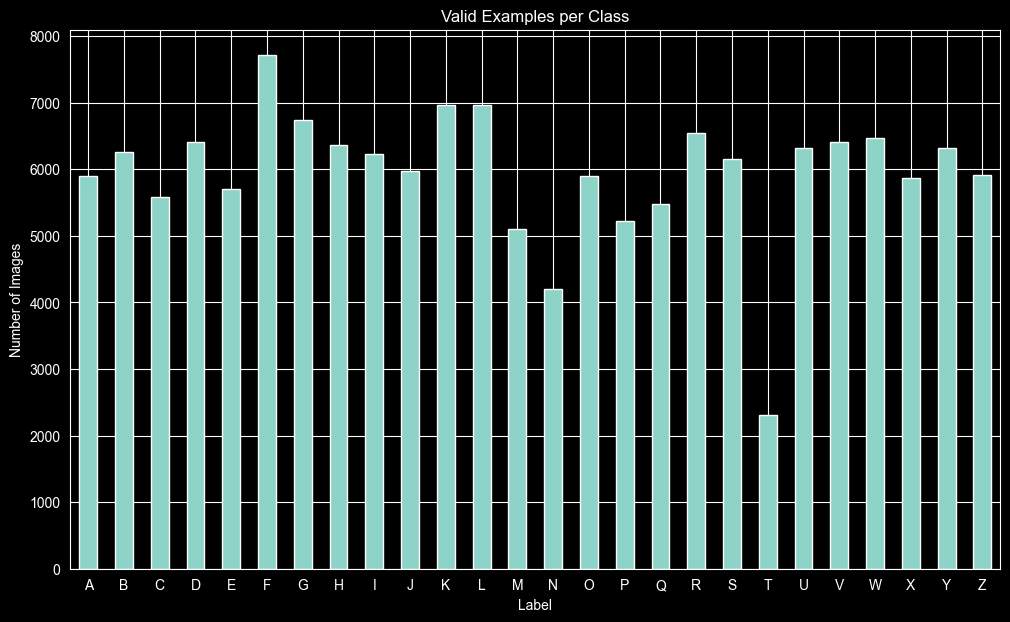

In [10]:
ax = label_counts.plot(kind="bar")
ax.set_title("Valid Examples per Class")
ax.set_xlabel("Label")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

In [10]:
print(f"Class with the fewest examples: {label_counts.idxmin()} -> {label_counts.min():,}")
print(f"Class with the most examples: {label_counts.idxmax()} -> {label_counts.max():,}")
print(f"Max/min ratio: {label_counts.max() / label_counts.min():.2f}x")

Class with the fewest examples: N -> 4,199
Class with the most examples: F -> 7,711
Max/min ratio: 1.84x


## Detected Handedness and MediaPipe Confidence

`handedness` indicates whether MediaPipe classified the hand as right or left. `score` is the confidence of this classification, not necessarily the absolute quality of the landmarks.

In [11]:
handedness_counts = df["handedness"].value_counts(dropna=False)
handedness_counts

handedness
Right    140058
Left      18525
Name: count, dtype: int64

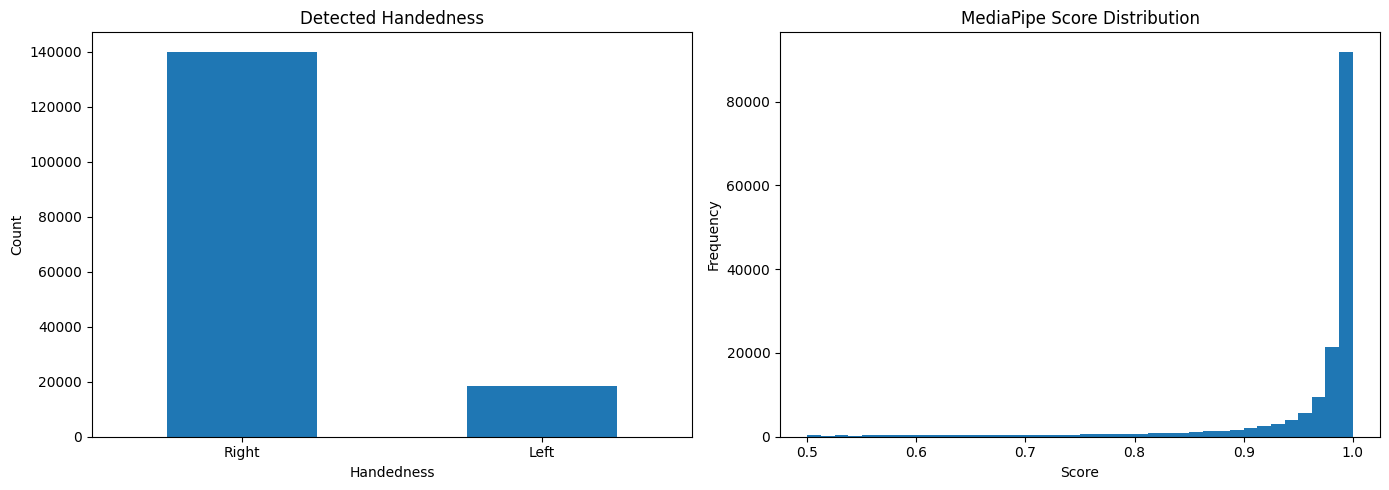

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

handedness_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Detected Handedness")
axes[0].set_xlabel("Handedness")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df["score"].plot(kind="hist", bins=40, ax=axes[1])
axes[1].set_title("MediaPipe Score Distribution")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.show()

## Landmark Coordinate Ranges

The coordinates are normalized: they are not pixels and do not directly depend on the image size. Very large values may indicate extreme poses, unstable landmarks, or unusual images.

In [13]:
coords = df[landmark_cols]

coord_summary = pd.DataFrame({
    "min": coords.min(),
    "mean": coords.mean(),
    "std": coords.std(),
    "max": coords.max(),
})

coord_summary.head(15)

,min,mean,std,max
x0,0.000000,0.000000,0.000000,0.000000
y0,0.000000,0.000000,0.000000,0.000000
z0,0.000000,0.000000,0.000000,0.000000
x1,-2.332694,0.249410,0.237080,2.061546
y1,-1.473594,-0.170004,0.175431,1.107822
z1,-1.168969,-0.161669,0.127357,0.496072
x2,-4.613595,0.380410,0.451412,3.004471
y2,-3.447718,-0.449802,0.341983,1.682643
z2,-1.449234,-0.234563,0.194180,0.729004
x3,-6.752411,0.311425,0.604486,3.460334


In [14]:
abs_coords = coords.abs()
largest_abs = abs_coords.max().sort_values(ascending=False).head(15)

largest_abs

x4     8.950675
y4     8.059526
y8     7.083980
x3     6.752411
y12    6.698736
y3     6.035114
y7     5.919993
y11    5.791425
x8     5.624702
x20    5.029846
x19    4.815899
y14    4.786839
y15    4.621967
x2     4.613595
y16    4.544370
dtype: float64

## Landmark Visualization

This section draws the hand skeleton using only the coordinates stored in the CSV. It does not use the original image: it helps verify whether the features make sense for the model.

In [15]:
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (0, 9), (9, 10), (10, 11), (11, 12),
    (0, 13), (13, 14), (14, 15), (15, 16),
    (0, 17), (17, 18), (18, 19), (19, 20),
    (5, 9), (9, 13), (13, 17),
]


def row_to_points(row):
    return np.array([[row[f"x{i}"], row[f"y{i}"], row[f"z{i}"]] for i in range(21)], dtype=float)


def draw_hand(ax, row, title=None):
    points = row_to_points(row)
    x = points[:, 0]
    y = -points[:, 1]

    for start, end in HAND_CONNECTIONS:
        ax.plot([x[start], x[end]], [y[start], y[end]], linewidth=2)

    ax.scatter(x, y, s=25, zorder=3)
    ax.scatter([x[0]], [y[0]], s=80, marker="x", zorder=4, label="wrist")
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    if title:
        ax.set_title(title)

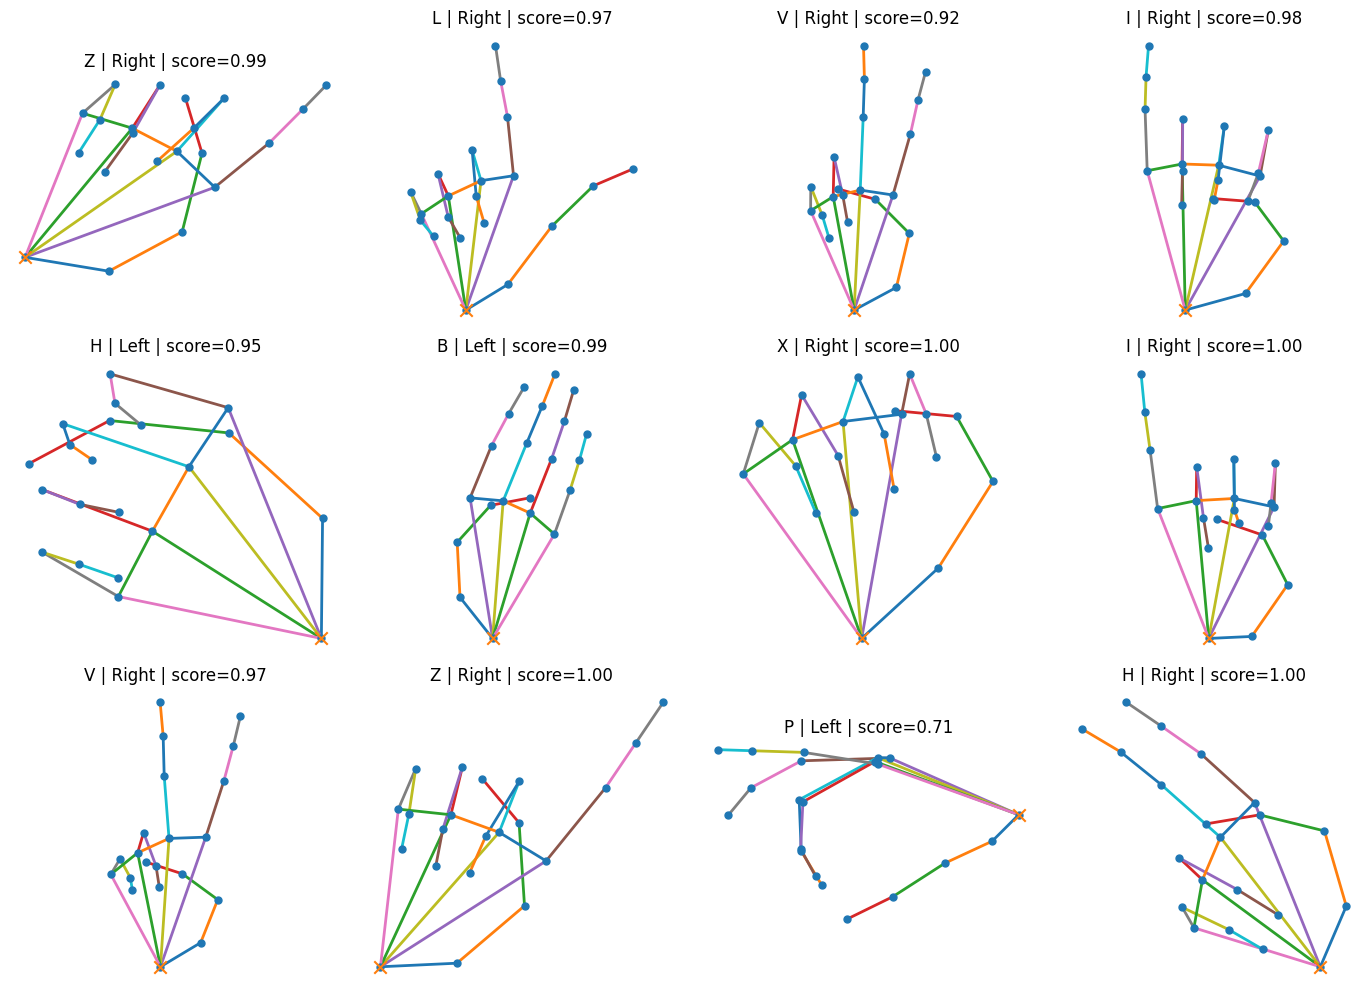

In [16]:
sample = df.sample(12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    title = f"{row['label']} | {row['handedness']} | score={row['score']:.2f}"
    draw_hand(ax, row, title)

plt.tight_layout()
plt.show()

## Average Hand per Class

Here we compute an average hand shape for a few classes. This is not meant as a training metric, but it helps show whether classes have distinguishable geometric patterns.

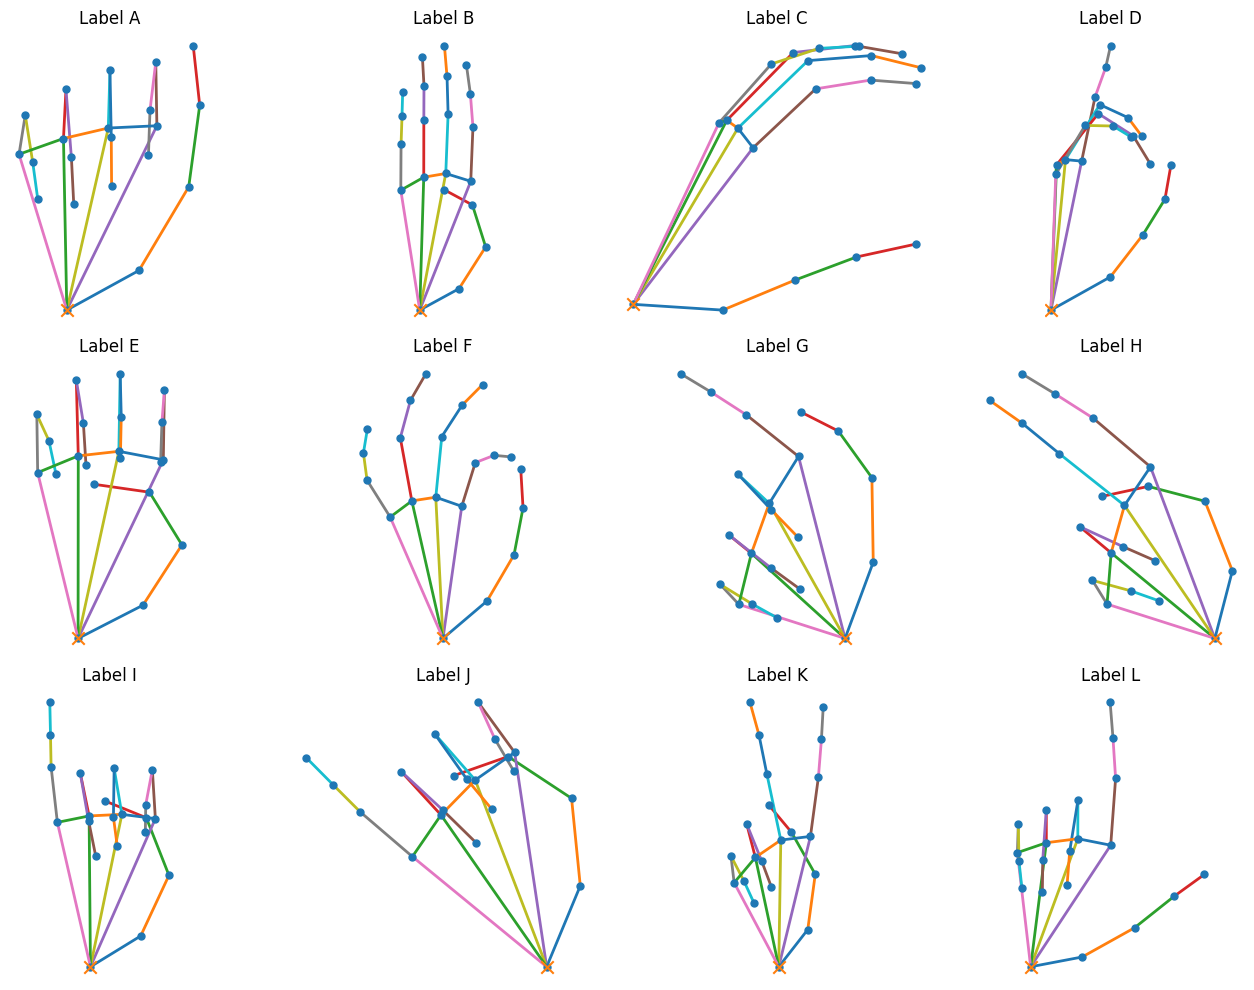

In [17]:
labels_to_show = sorted(df["label"].unique())[:12]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, label in zip(axes.flat, labels_to_show):
    mean_row = df[df["label"] == label][landmark_cols].mean()
    draw_hand(ax, mean_row, f"Label {label}")

plt.tight_layout()
plt.show()

## Simple Coordinate Outliers

This check looks for rows with very large normalized coordinates. That does not automatically mean they are wrong, but they are good candidates to inspect if the model behaves poorly.

In [18]:
df_outlier = df.copy()
df_outlier["max_abs_coord"] = df_outlier[landmark_cols].abs().max(axis=1)

df_outlier[["filepath", "label", "handedness", "score", "max_abs_coord"]] \
    .sort_values("max_abs_coord", ascending=False) \
    .head(20)

,filepath,label,handedness,score,max_abs_coord
14485,data\ASL_Alphabet_Dataset\asl_alphabet_train\C...,C,Left,0.942728,8.950675
145000,data\ASL_Alphabet_Dataset\asl_alphabet_train\X...,X,Left,0.980106,8.059526
143341,data\ASL_Alphabet_Dataset\asl_alphabet_train\X...,X,Left,0.980106,8.059526
14593,data\ASL_Alphabet_Dataset\asl_alphabet_train\C...,C,Left,0.994328,7.926675
14572,data\ASL_Alphabet_Dataset\asl_alphabet_train\C...,C,Right,0.789219,6.532272
17215,data\ASL_Alphabet_Dataset\asl_alphabet_train\C...,C,Right,0.520630,4.300326
12761,data\ASL_Alphabet_Dataset\asl_alphabet_train\C...,C,Right,0.520630,4.300326
55499,data\ASL_Alphabet_Dataset\asl_alphabet_train\I...,I,Left,0.518675,4.187324
53072,data\ASL_Alphabet_Dataset\asl_alphabet_train\I...,I,Left,0.518675,4.187324
13867,data\ASL_Alphabet_Dataset\asl_alphabet_train\C...,C,Left,0.521635,4.152805


## Feature/Target Matrix for Training

For a basic ASL classifier on the valid dataset:

- `X`: the 63 landmark columns (`x0,y0,z0 ... x20,y20,z20`);
- `y`: the `label` column.

Metadata columns such as `filepath`, `handedness`, `score`, `image_width`, and `image_height` remain useful for analysis/debugging, but they are not required as basic model features.

In [ ]:
X = df[landmark_cols].astype("float32")
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", sorted(y.unique()))

## Final Notes

This dataset is already in a very convenient format for training: it is independent of image resolution and hand position in the frame because it uses wrist-relative coordinates scaled by hand size.

The rejected samples in `asl_landmarks_failed.csv` are not part of this dataset: they are images where MediaPipe did not produce a valid hand, so they do not have usable landmarks without a separate recovery step.